# 📜 Important Info 📜

This Notebook should be used in conjunction with a EDA notebook to identify feature engineering techniques: 
* Skewness
* Correlation 
* Outliers

In [1]:
target = "Class"

project_purpose = "Credit Card Fraud"
metric = "ROC_AUC"

train_data_dir = "/kaggle/input/playground-series-s3e4/train.csv"
test_data_dir = "/kaggle/input/playground-series-s3e4/test.csv"
submission_dir = "/kaggle/input/playground-series-s3e4/sample_submission.csv"

# 🏠 Load libraries & data 🏠

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, RepeatedStratifiedKFold,StratifiedKFold
from scipy.stats import boxcox, median_abs_deviation
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer

import shap
import lightgbm as lgb
import catboost as cat
import xgboost as xgb
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

#### Project Parameters
This determines how and what will be run

In [3]:
sns.set_style("darkgrid")
pd.set_option('mode.chained_assignment',None)

EPOCHS = 10000

SCALING = True
OUTLIERS = True
DISTRIBUTION = True
SMOTE_over = False

ADD_DATA = True
CALIBRATION = "linear" #gaus #CV

DEBUG = False

In [4]:
df_train = pd.read_csv(train_data_dir, index_col = 0)
df_test = pd.read_csv(test_data_dir, index_col = 0)
sub = pd.read_csv(submission_dir,index_col = 0)

In [5]:
if DEBUG: 
    print("Debug on")
    df_train = df_train.sample(frac= 0.15)

# 📃 Basic Analysis 📃

In [6]:
df_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
id,,,,,,,,,,,,,,,,,,,,,
0,0.0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,-0.263477,0.742144,...,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,1.98,0
1,0.0,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,0.050198,-0.109948,...,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,84.00,0
2,0.0,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,-0.084789,-0.042027,...,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,2.69,0
3,0.0,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,-0.035367,0.885838,...,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,1.00,0
4,0.0,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,0.569239,0.692665,...,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,1.00,0


In [7]:
numerical = [col for col in df_train.select_dtypes(exclude = "object").columns if col not in [target]]
categorical = [col for col in df_train.select_dtypes("object").columns if col!=target]
print("Numerical Columns:",numerical)
print("Categorical Columns:",categorical)

Numerical Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Categorical Columns: []


In [8]:
# We concatenate test data to train to get a full view of the data as we know it
df_all = pd.concat((df_train.drop(target,axis =1), df_test), axis =0)
skew_df = df_all.skew(numeric_only=True).sort_values()
skew_df

V8       -6.226413
V2       -2.133144
V27      -1.960943
V1       -1.500688
V12      -1.143887
V14      -0.837920
V3       -0.671229
V16      -0.429349
V15      -0.287975
V25      -0.287102
V24      -0.256266
V22      -0.160918
V18      -0.123484
V17      -0.102438
V7       -0.051443
Time     -0.011402
V19       0.009196
V13       0.026512
V11       0.072439
V9        0.345507
V5        0.501446
V4        0.534661
V23       0.556205
V26       0.685888
V10       1.221894
V20       1.326512
V6        1.430481
V21       4.695502
V28       8.127985
Amount    8.903529
dtype: float64

In [9]:
skew_cols = list(skew_df[(skew_df<1)& (skew_df>-1)].index)
print([col for col in skew_cols])

['V14', 'V3', 'V16', 'V15', 'V25', 'V24', 'V22', 'V18', 'V17', 'V7', 'Time', 'V19', 'V13', 'V11', 'V9', 'V5', 'V4', 'V23', 'V26']


In [10]:
#remove low skewness 
for i in list(skew_df[skew_df==0].index):
    try:
        skew_cols.remove(i)
    except: 
        print("column not present")

In [11]:
# Add outlier columns here 
outliers = [] #["Amount"]

# 🎯 Feature Engineering 🎯

In [12]:
df_trn = df_train.copy(deep = True)
df_tst = df_test.copy(deep = True)

In [13]:
if ADD_DATA: 
    add_data = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')

    df_trn['is_generated'] = 1
    df_tst['is_generated'] = 1
    add_data['is_generated'] = 0

    df_trn = pd.concat([df_trn, add_data],axis=0, ignore_index=True)

In [14]:
df_trn['hour'] = df_trn['Time'] % (24 * 3600) // 3600
df_trn['day'] = (df_trn['Time'] // (24 * 3600)) % 7

df_tst['hour'] = df_tst['Time'] % (24 * 3600) // 3600
df_tst['day'] = (df_tst['Time'] // (24 * 3600)) % 7

As per this [notebook](https://www.kaggle.com/code/samir95/i-found-the-perfect-cross-validation/notebook), our Test and Train data arent during different times of the day 

In [15]:
df_trn = df_trn[df_trn["hour"]>=10]

In [16]:
def integer_part(df):
    '''
    Extract the integer and decimal part of the transaction...
    '''
    df['Decimal'] = df['Amount'] % 1
    df['Integer'] = df['Amount'] - df['Decimal']
    
    return df

def across_col_feat(df):
    '''
    Calculates features across colums...
    '''
    features = [feat for feat in df.columns if 'V' in feat]
    df['V_Sum'] = df[features].sum(axis = 1)
    df['V_Min'] = df[features].min(axis = 1)
    df['V_Max'] = df[features].max(axis = 1)
    df['V_Avg'] = df[features].mean(axis = 1)
    df['V_Std'] = df[features].std(axis = 1)
    df['V_Pos'] = df[features].gt(0).sum(axis = 1)
    df['V_Neg'] = df[features].lt(0).sum(axis = 1)
    #df['V_Mad'] = df[features].mad(axis = 1)
    #df['V_Range'] = abs(df['V_Min'] - df['V_Max'])
    return df

def flag_duplicates(df, remove = True):
    '''
    Flag the dataframe to indicate if there are duplicates
    '''
    v_features = [x for x in df.columns if x not in ['id', 'Time']]
    df['Duplicate'] = 0
    df.loc[df[v_features].duplicated(keep = False), 'Duplicate'] = 1
    
    if remove:
        df = df[df['Duplicate'] == 0]
        
    return df

# df_trn = flag_duplicates(df_trn) 
# df_tst = flag_duplicates(df_tst, remove = False) 

df_trn = across_col_feat(df_trn)
df_tst = across_col_feat(df_tst)
df_trn = integer_part(df_trn)
df_tst = integer_part(df_tst)

#### Drop cols 
From investigation into your Base model below we note certain features that have a zero feature importance. We will remove these 

In [17]:
drop_cols =  ["V25", "Time"]
df_trn.drop(drop_cols,axis =1,inplace = True)
df_tst.drop(drop_cols,axis =1,inplace = True)

# 🦥 Correlation w/ PCA 🦥
Correlation will negatively impact certain models as this can cause overfitting 

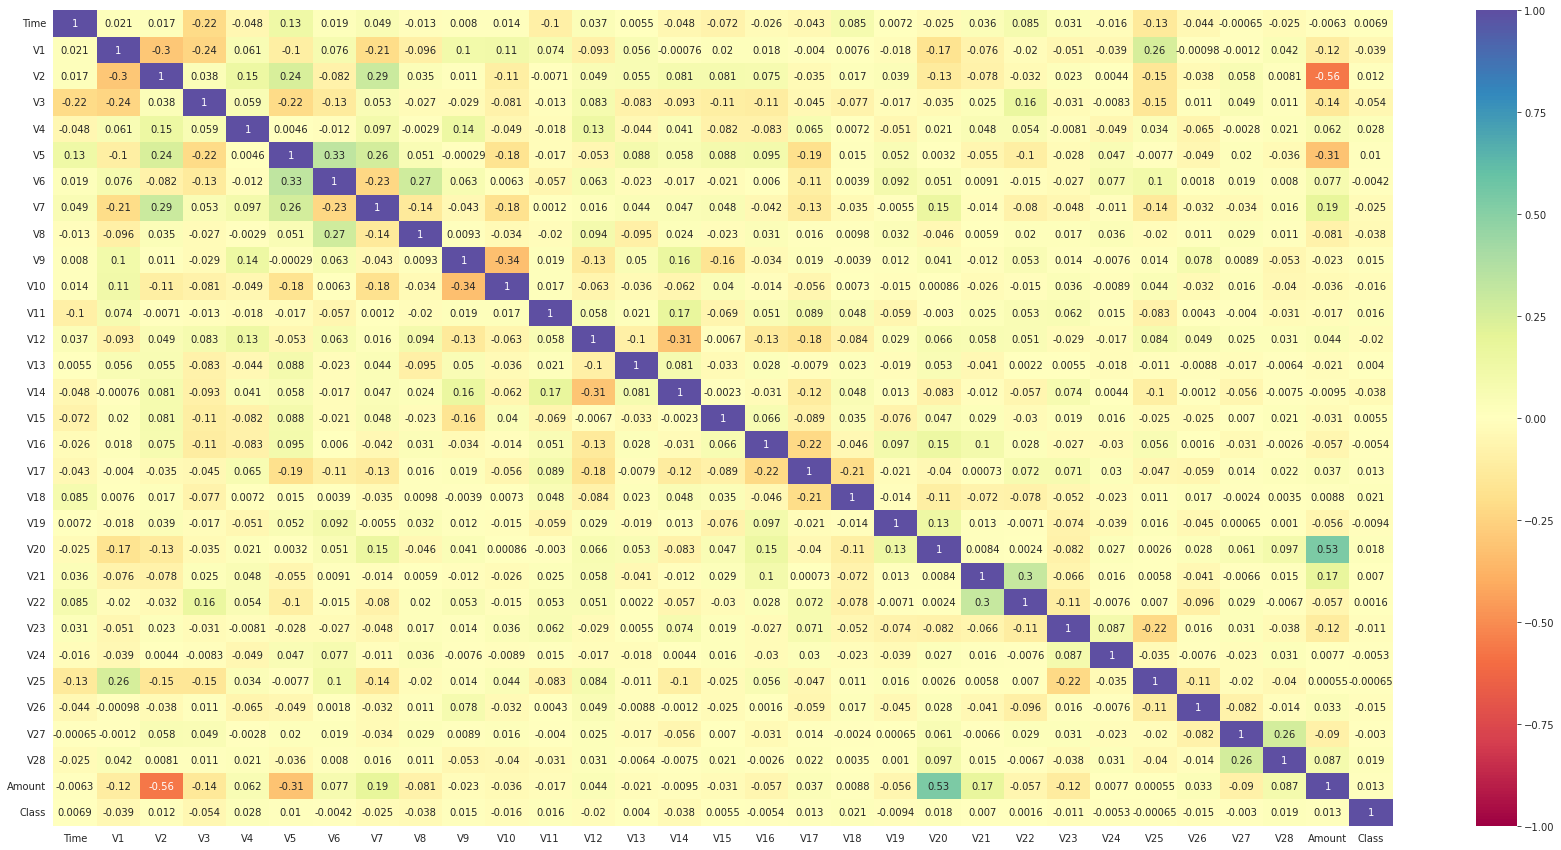

In [18]:
plt.figure(figsize = (30,15))
sns.heatmap(df_train.corr(),vmin = -1, vmax = 1, cmap = "Spectral",annot=True)
plt.show()

<span style="color:red;font-size:1.3em;">Potential Solutions: Reduce Overfitting =====PCA</span>
1. Apply dimensionality reduction techniques i.e. PCA 


In [19]:
from sklearn.decomposition import PCA

In [20]:
pca_cols = ["Amount","V2","V3"]

pca_ = PCA(n_components=2 ,whiten= False)
df_trn[["pca_amt_v2_v3_a","pca_amt_v2_v3_b"]] = pca_.fit_transform(df_trn[pca_cols])
df_tst[["pca_amt_v2_v3_a","pca_amt_v2_v3_b"]] = pca_.transform(df_tst[pca_cols])

for df in [df_trn,df_tst]:
    df.drop(pca_cols, axis =1, inplace = True)
    
df_trn[["pca_amt_v2_v3_a","pca_amt_v2_v3_b"]]

,pca_amt_v2_v3_a,pca_amt_v2_v3_b
28639,-81.520163,-0.087135
28640,211.700537,-0.851605
28641,-77.753955,-0.632045
28642,-8.511491,-0.935567
28643,-83.382318,-0.770104
...,...,...
503931,-82.754130,13.812957
503932,-58.712699,-1.558597
503933,-15.615076,2.877592
503934,-73.502973,-0.126053


## Split

In [21]:
X = df_trn.drop([target],axis =1)
y = df_trn[target]

# ⚖️ Scaling & Smote ⚖️

In [22]:
def Scaling(X_train, X_test, test_df,  y_train, X= None,) : 
    
    """Scaling and Sampling Helper function: 
        Scales and oversamples training and validation dataframes 
    
    :param 
        X_train: pandas dataframe of training data , less target values
        X_test: pandas dataframe of validation data , less target values
        test_df: pandas dataframe of test data , less target values
        y_train: pandas dataframe or series of target training values
        X: pandas dataframe of training and validation data, less target values
        
    :return: scaled input paramaters as pandas dataframes 

    """
    
    test_s = test_df.copy(deep = True)
    X_train_s = X_train.copy(deep = True)
    X_test_s = X_test.copy(deep = True)
    
    if X is not None:
        X_s = X.copy(deep = True)
    
    if OUTLIERS and len(outliers)>0:
        #Scale outliers: see boxplots
        scaler = RobustScaler()
        X_train_s[outliers] = scaler.fit_transform(X_train_s[outliers])
        X_test_s[outliers]  = scaler.transform(X_test_s[outliers])
        test_s[outliers] = scaler.transform(test_s[outliers])
        if X is not None:
            X_s[outliers] = scaler.transform(X_s[outliers])
    
    if DISTRIBUTION:
        #Scale Skewness: see distribution
        scaler = QuantileTransformer(output_distribution="normal")
        X_train_s = scaler.fit_transform(X_train_s)
        X_test_s = scaler.transform(X_test_s)
        test_s = scaler.transform(test_s)
        if X is not None:
            X_s = scaler.transform(X_s)
            
    if SCALING: 
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train_s)
        X_test_s = scaler.transform(X_test_s)
        test_s = scaler.transform(test_s)
        if X is not None:
            X_s = scaler.transform(X_s)
    
    if SMOTE_over:
        smt = SMOTE()
        X_train_s, y_train = smt.fit_resample(X_train_s, y_train)
              
    if X is not None:
        return pd.DataFrame(X_train_s, columns = X.columns )   , pd.DataFrame(X_test_s, columns = X.columns ) , pd.DataFrame(test_s, columns = test_df.columns ) , pd.DataFrame(X_s, columns = X.columns ),  y_train  
    else:
        return pd.DataFrame(X_train_s, columns = X.columns ), pd.DataFrame(X_test_s, columns = X.columns )  , pd.DataFrame(test_s, columns = test_df.columns ), y_train

# 🧊  Muti-Model Testing 🧊 


In [23]:
# Note: scale_pos_weight is total majoriity / total minority class ==1477/200
class_pos_weight =   (len(df_trn) - sum(df_trn[target]))/sum(df_trn[target])
print("scale_pos_weight:",class_pos_weight)

skew_cols = [col for col in skew_cols if col not in drop_cols]

#Potential: to square root this value as it is very imbalanced : see this post https://stats.stackexchange.com/questions/243207/what-is-the-proper-usage-of-scale-pos-weight-in-xgboost-for-imbalanced-datasets
# class_pos_weight = np.sqrt(class_pos_weight)
# print("sqrtscale_pos_weight", class_pos_weight)

scale_pos_weight: 623.3462157809984


In [24]:
lgb_params ={'objective': 'binary',
             'metric': 'auc',
             "boosting": "gbdt",#"dart",
#              'lambda_l1': 1.0050418664783436e-08, 
#              'lambda_l2': 9.938606206413121,
             'scale_pos_weight': class_pos_weight, 
#              'num_leaves': 44,
#              'feature_fraction': 0.8247273276668773,
#              'bagging_fraction': 0.5842711778104962,
#              'bagging_freq': 6,
#              'min_data_in_leaf': 134,
#              'min_child_samples': 70,
#              'max_depth': 8,
             'num_iterations':EPOCHS,
             'learning_rate':0.1,
            'device':'cpu'}
    
xgb_params = { 
    'scale_pos_weight':class_pos_weight, 
              'n_estimators' : EPOCHS, 
              'early_stopping_rounds' :30,
             #'tree_method':'gpu_hist'
             }
cat_params = {'iterations':EPOCHS,
              'eval_metric' : "AUC" ,
              "scale_pos_weight": class_pos_weight,
             #'task_type':"GPU"
             }
ET_params = {'max_depth':6}
RF_params = {'class_weight' : 'balanced',
             'max_depth':8}

In [25]:
# Comment out the models below to include in the Crossvalidation 

models = {
#     "LogisticRegression": LogisticRegression(max_iter = 10000),
#     "Ridge": RidgeClassifier(class_weight='balanced',max_iter = 10000,alpha = 0.2),
    #"SVC":SVC(probability=True, kernel = "rbf",class_weight='balanced'),
     "lightgbm": lgb.LGBMClassifier(**lgb_params), 
    "xgboost": xgb.XGBClassifier(**xgb_params,), 
    "catboost": cat.CatBoostClassifier(**cat_params),
#      "ExtraTreeClassifier": ExtraTreesClassifier(),
#      "RandomForestClassifier":RandomForestClassifier(**RF_params)
}

In [26]:
# We use Stratified Kfold due to the class imbalance
kfold= StratifiedKFold(n_splits=5)

## Cross Validation

In [27]:
test_preds =[]
train_preds = []
model_shap_values = []

OOF_val_score =[]
OOF_val_loss =[]

for name,model in models.items():
    score_train = []
    score_val= []
    score_loss = []
    
    #Shap stuff
    list_shap_values = []
    full_val_index = []
    
    in_fold_trn_preds = []   
    in_fold_preds = []
    print("\n######",name,"######")

    for fold, (train_idx,val_idx) in enumerate(kfold.split(X,y)):
        X_train,y_train = X.iloc[train_idx,:], y.iloc[train_idx]
        X_test,y_test = X.iloc[val_idx,:], y.iloc[val_idx]
        
        #Scaling
        if name in ["LogisticRegression",'Ridge']:
            scaler = StandardScaler()
            X_train_s = scaler.fit_transform(X_train)
            X_test_s  = scaler.transform(X_test)
            X_temp = X.copy(deep = True)
            X_temp = scaler.transform(X_temp)
            test_temp = scaler.transform(df_tst)
        else:
            X_train_s, X_test_s , test_temp, X_temp, y_train = Scaling(X_train, X_test , df_tst, y_train, X )
        
        #Fit
        if name in ["lightgbm", "xgboost"]:
            model.fit(X_train_s,y_train,
                     eval_set=[(X_test_s,y_test)],
                      eval_metric=["auc"],
                      verbose= 0
                     )
        elif name in [ "catboost"]:
            model.fit(X_train_s,y_train,
                      eval_set=[(X_test_s,y_test)],
                      early_stopping_rounds=30,
                      verbose= 0
                     )          
        else:
            model.fit(X_train_s,y_train)
            
        # Predict
        if name in ["Ridge"]:
            y_preds = model.predict(X_test_s)
            y_trn_preds = model.predict(X_temp)
            in_fold_trn_preds.append(y_trn_preds)
            in_fold_preds.append(model.predict(test_temp))
        else:
            y_preds = model.predict_proba(X_test_s)[:,1]
            y_trn_preds = model.predict_proba(X_temp)[:,1]
            in_fold_trn_preds.append(y_trn_preds )
            in_fold_preds.append(model.predict_proba(test_temp)[:,1] )
        
        score_val.append(roc_auc_score(y_test,y_preds))
        score_loss.append(log_loss(y_test,y_preds))
        score_train.append(roc_auc_score(y,y_trn_preds))
        
        # Create Shap values 
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_s)
        #for each fold we save the validation index and the shap_values
        list_shap_values.append(shap_values)
        full_val_index.append(val_idx)
        
            
    model_shap_values.append(list_shap_values)
    
    OOF_val_score.append(np.mean(score_val))
    OOF_val_loss.append(np.mean(score_loss))
    train_preds.append(np.mean(in_fold_trn_preds,axis=0))
    test_preds.append(np.mean(in_fold_preds,axis=0))

    print("MEAN Trn AUC:",np.mean(score_train))
    print("MEAN Val AUC:",np.mean(score_val))
    print("MEAN logloss:",np.mean(score_loss))


###### lightgbm ######


'verbose' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
Found `num_iterations` in params. Will use it instead of argument


[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
'verbose' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
Found `num_iterations` in params. Will use it instead of argument


[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt


...

[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


MEAN Trn AUC: 0.808984832337081
MEAN Val AUC: 0.7263105973208898
MEAN logloss: 4.276746203133171

###### xgboost ######


`eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
ntree_limit is deprecated, use `iteration_range` or model slicing instead.
`eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
ntree_limit is deprecated, use `iteration_range` or model slicing instead.
`eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
ntree_limit is deprecated, use `iteration_range` or model slicing instead.
`eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
ntree_limit is deprecated, use `iteration_range` or model slicing instead.
`eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor

MEAN Trn AUC: 0.9688927616302486
MEAN Val AUC: 0.8358409166523962
MEAN logloss: 0.20749332254512892

###### catboost ######
MEAN Trn AUC: 0.9452428970018942
MEAN Val AUC: 0.8918912069884597
MEAN logloss: 0.373079169670144


# ⚡️⚡️ Shap with CrossValidation ⚡️⚡️
Adapted from [this blogpost](https://towardsdatascience.com/using-shap-with-cross-validation-d24af548fadc) and [this one](https://lucasramos-34338.medium.com/visualizing-variable-importance-using-shap-and-cross-validation-bd5075e9063a)

In [28]:
#Create index of the validation sets 
val_index_ = np.concatenate(full_val_index).ravel()
# create a dataframe of the validation-set indexes
X_shap = pd.DataFrame(X_temp.iloc[val_index_])

In [29]:
# # LIGHTGBM --note the extra index for lightgbm (see shap example for lgb )
shap_values_lgb = model_shap_values[0][0][1]
shap_values_xgb = model_shap_values[1][0]
shap_values_cat = model_shap_values[2][0]

for i in range(1,len(model_shap_values[0])): 
    shap_values_lgb = np.concatenate((shap_values_lgb,np.array(model_shap_values[0][i][1])),axis=0)
    shap_values_xgb = np.concatenate((shap_values_xgb,np.array(model_shap_values[1][i])),axis=0)
    shap_values_cat = np.concatenate((shap_values_cat,np.array(model_shap_values[2][i])),axis=0)

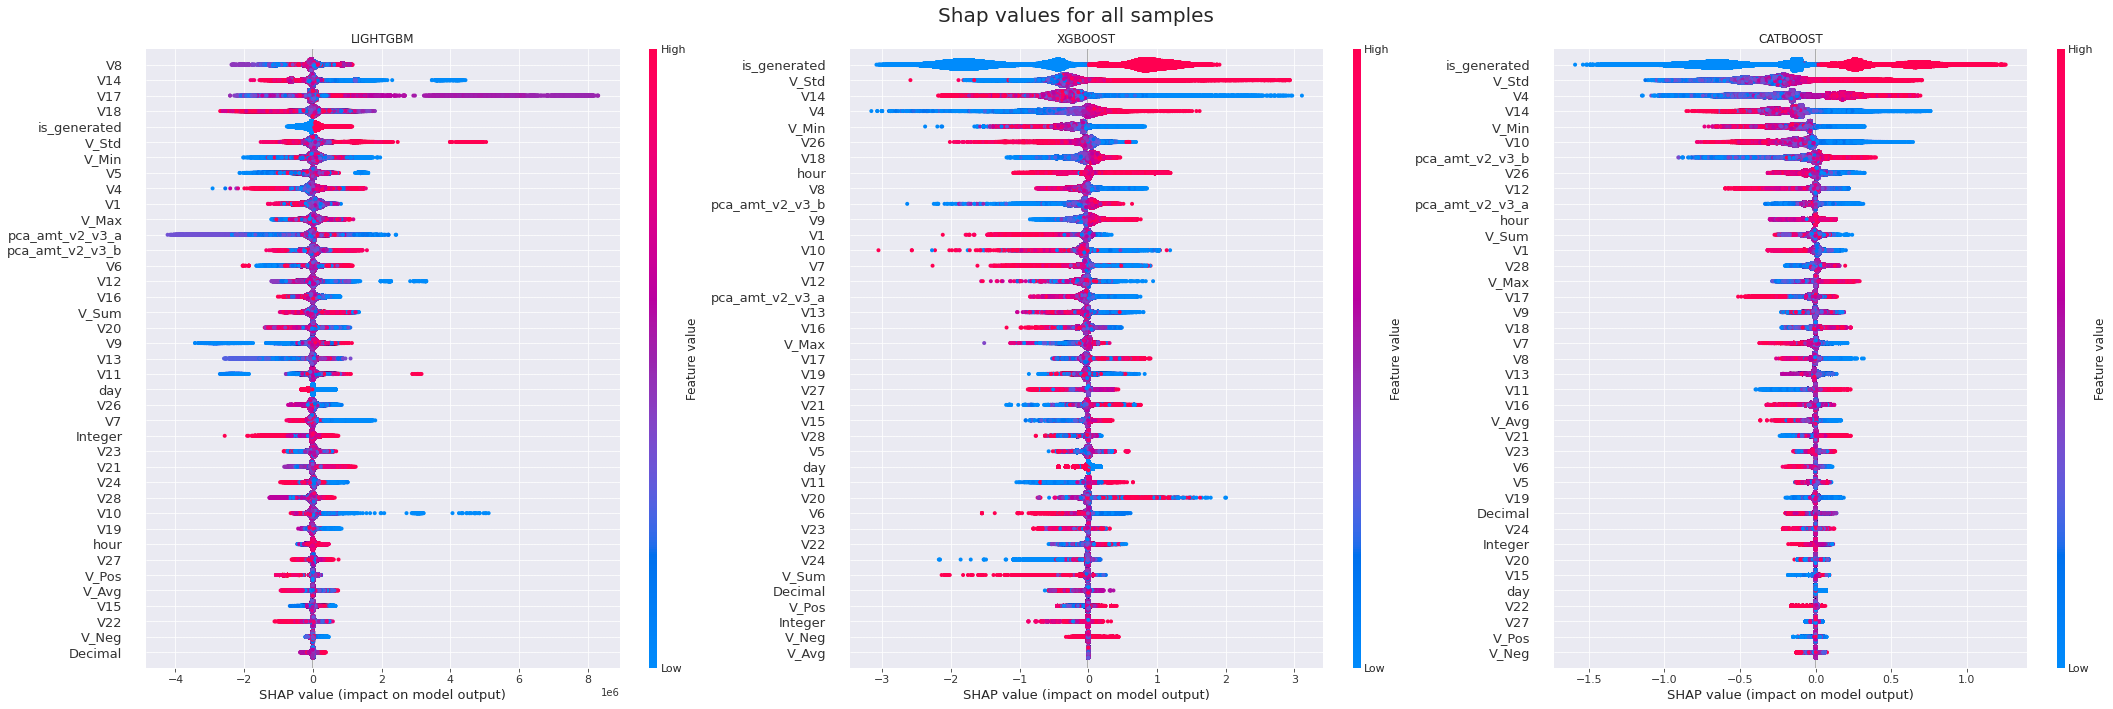

In [30]:
fig = plt.figure()
ax0 = fig.add_subplot(131)
shap.summary_plot(shap_values_lgb, X_shap,  max_display = 500, plot_size=[30,15], show = False)
ax1 = fig.add_subplot(132)
shap.summary_plot(shap_values_xgb, X_shap,  max_display = 500, plot_size=[30,15], show = False)
ax2 = fig.add_subplot(133)
shap.summary_plot(shap_values_cat, X_shap,  max_display = 500, plot_size=[30,15], show = False)
plt.gcf().set_size_inches(30,10)
fig.suptitle("Shap values for all samples",fontsize = 20)
ax0.title.set_text("LIGHTGBM")
ax1.title.set_text("XGBOOST")
ax2.title.set_text("CATBOOST")
plt.tight_layout() 
plt.show()

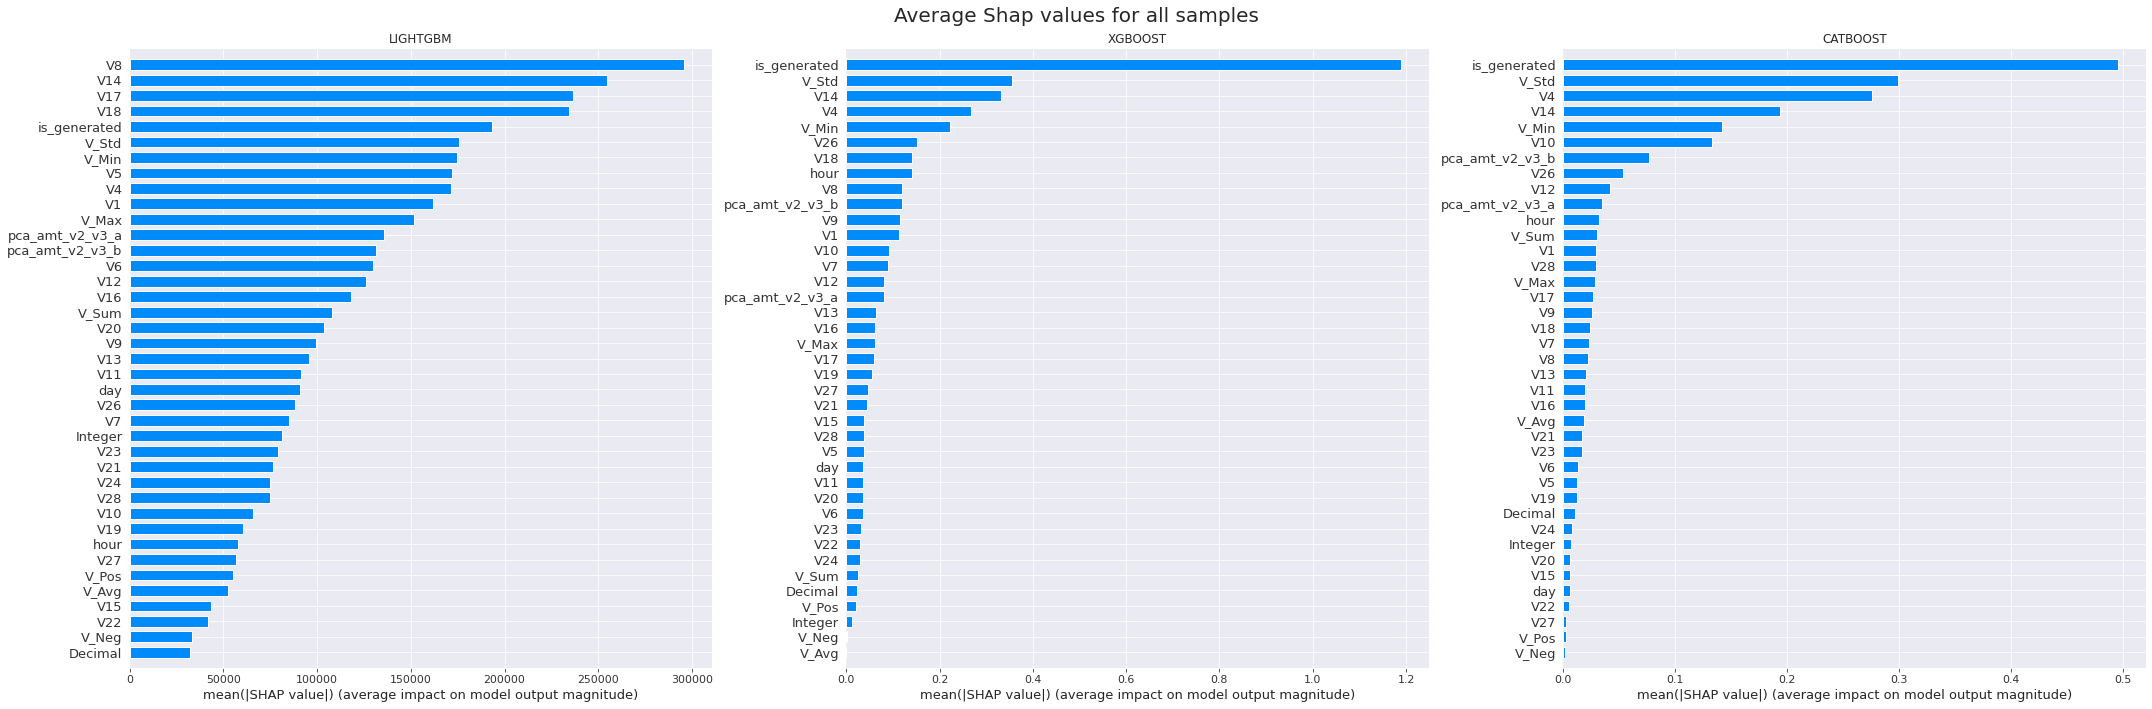

In [31]:
fig = plt.figure()
ax0 = fig.add_subplot(131)
shap.summary_plot(shap_values_lgb, X_shap,  max_display = 500, plot_size=[30,15], show = False, plot_type="bar")
ax1 = fig.add_subplot(132)
shap.summary_plot(shap_values_xgb, X_shap,  max_display = 500, plot_size=[30,15], show = False, plot_type="bar")
ax2 = fig.add_subplot(133)
shap.summary_plot(shap_values_cat, X_shap,  max_display = 500, plot_size=[30,15], show = False, plot_type="bar")
plt.gcf().set_size_inches(30,10)
fig.suptitle("Average Shap values for all samples",fontsize = 20)
ax0.title.set_text("LIGHTGBM")
ax1.title.set_text("XGBOOST")
ax2.title.set_text("CATBOOST")
plt.tight_layout() 
plt.show()

In [32]:
# create submission dataframes
sub[target]  = 0
sub_ensemble = sub.copy(deep= True)
mean_ensemble = sub.copy(deep= True)
sub_cal = sub.copy(deep = True)
sub_lgb  = sub.copy(deep = True)
sub_xgb  = sub.copy(deep = True)
sub_cat  = sub.copy(deep = True)

# 🍡 Ensembling 🍡

#### 1. weighted

In [33]:
for i, preds in enumerate(test_preds):
    sub_ensemble[target] = sub_ensemble[target] + (test_preds[i] * OOF_val_score[i]) #multiple preds by their corresponding auc score
    
sub_ensemble[target] =   sub_ensemble[target]/ sum(OOF_val_score) 
sub_ensemble[target]

id
219129    0.287974
219130    0.285930
219131    0.156586
219132    0.314802
219133    0.208194
            ...   
365211    0.195187
365212    0.229317
365213    0.241770
365214    0.217259
365215    0.252376
Name: Class, Length: 146087, dtype: float64

#### 2. mean

In [34]:
# Get a dataframe of train and test predictions 
all_trn_preds = pd.DataFrame(index = df_trn.index)
all_tst_preds = pd.DataFrame(index = df_tst.index)

for i, preds in enumerate(train_preds):
    all_trn_preds[f"{list(models.keys())[i]}_{OOF_val_score[i]}"] = train_preds[i]
    all_tst_preds[f"{list(models.keys())[i]}_{OOF_val_score[i]}"] = test_preds[i]
all_tst_preds

,lightgbm_0.7263105973208898,xgboost_0.8358409166523962,catboost_0.8918912069884597
id,,,
219129,0.2,0.245651,0.399279
219130,0.2,0.222685,0.415177
219131,0.0,0.117568,0.320666
219132,0.2,0.276909,0.443802
219133,0.0,0.212457,0.373742
...,...,...,...
365211,0.0,0.223142,0.327938
365212,0.0,0.258789,0.388440
365213,0.0,0.308057,0.376534


In [35]:
# Get mean ensemble
mean_ensemble[target]= all_tst_preds.mean(axis = 1)

# 🚜 Calibration 🚜


In [36]:
if CALIBRATION == "CV":
    print(CALIBRATION)
    model = LogisticRegression(max_iter = 10000)
elif CALIBRATION=='gaus': 
    print(CALIBRATION)
    model = GaussianNB()
    print(CALIBRATION)
elif CALIBRATION=='CV':
    model = CalibratedClassifierCV(lin_model, method='isotonic', cv=5)

#Fit on training preds
model.fit(all_trn_preds, np.ravel(y))
# Predict test preds
y_cal_test  = model.predict_proba(all_tst_preds)[:,1]
y_cal_train  = model.predict_proba(all_trn_preds)[:,1]

Learning rate set to 0.015894
0:	total: 46ms	remaining: 7m 40s
1:	total: 88.8ms	remaining: 7m 24s
2:	total: 135ms	remaining: 7m 29s
3:	total: 178ms	remaining: 7m 25s
4:	total: 221ms	remaining: 7m 21s
5:	total: 263ms	remaining: 7m 17s
6:	total: 305ms	remaining: 7m 15s
7:	total: 346ms	remaining: 7m 12s
8:	total: 392ms	remaining: 7m 14s
9:	total: 434ms	remaining: 7m 13s
10:	total: 472ms	remaining: 7m 8s
11:	total: 514ms	remaining: 7m 7s
12:	total: 556ms	remaining: 7m 6s
13:	total: 599ms	remaining: 7m 7s
14:	total: 641ms	remaining: 7m 7s
15:	total: 686ms	remaining: 7m 7s
16:	total: 728ms	remaining: 7m 7s
17:	total: 769ms	remaining: 7m 6s
18:	total: 815ms	remaining: 7m 8s
19:	total: 859ms	remaining: 7m 8s
20:	total: 902ms	remaining: 7m 8s
21:	total: 944ms	remaining: 7m 8s
22:	total: 985ms	remaining: 7m 7s
23:	total: 1.02s	remaining: 7m 4s
24:	total: 1.06s	remaining: 7m 4s
25:	total: 1.1s	remaining: 7m 3s
26:	total: 1.15s	remaining: 7m 3s
27:	total: 1.19s	remaining: 7m 2s
28:	total: 1.23s	re

In [37]:
sub_cal[target] = 0 
sub_cal[target] = y_cal_test

## True only visualization 
Lets visualise only the Fraud cases as this is the most important class to analyse

In [38]:
y_true_only = y_test[y_test==1].reset_index(drop = True)

true_preds_lgb = train_preds[0][y_true_only.index]
true_preds_xgb= train_preds[1][y_true_only.index]
true_preds_cat= train_preds[2][y_true_only.index]
true_preds_cal = y_cal_train[y_true_only.index]

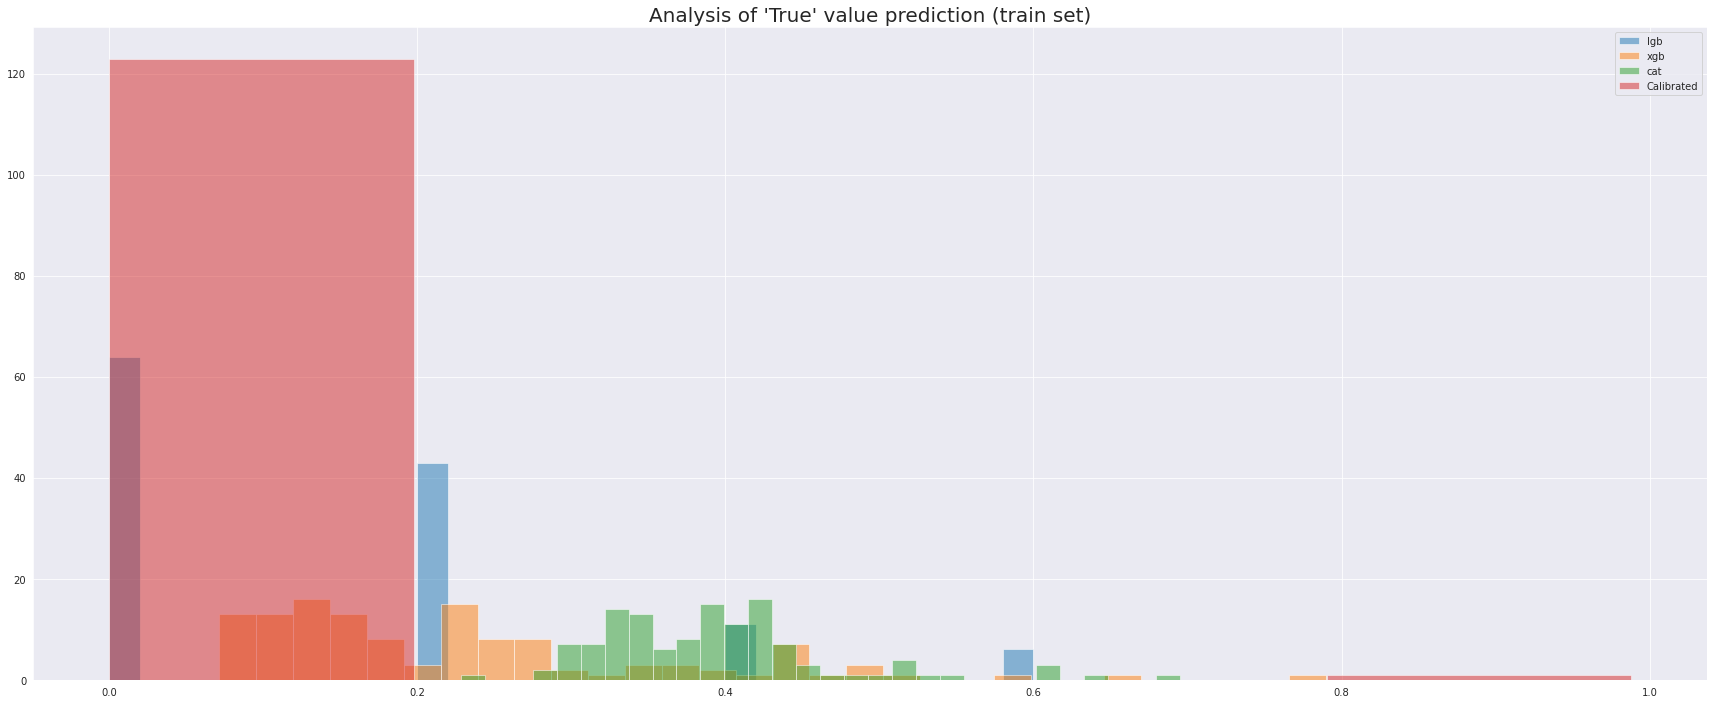

In [39]:
plt.figure(figsize = (30,12))
plt.hist(true_preds_lgb, label = "lgb", alpha = 0.5, bins = 30)
plt.hist(true_preds_xgb, label = "xgb", alpha = 0.5, bins = 30)
plt.hist(true_preds_cat, label = "cat", alpha = 0.5, bins = 30)
plt.hist(true_preds_cal, label = "Calibrated",alpha = 0.5, bins = 5)
plt.title("Analysis of 'True' value prediction (train set)", fontsize = 20)
plt.legend()
plt.show()

This is very interesting:
* Lightgbm seems to set the probability of True values to be approx 0.45 with very little change to this
* Catboost seems more wide spread 
* Xgboost looks to be the best option with more high probability predictions and fewer lower probability predictions 
* Calibrated is very poor, it essential sets everything to 0 probability

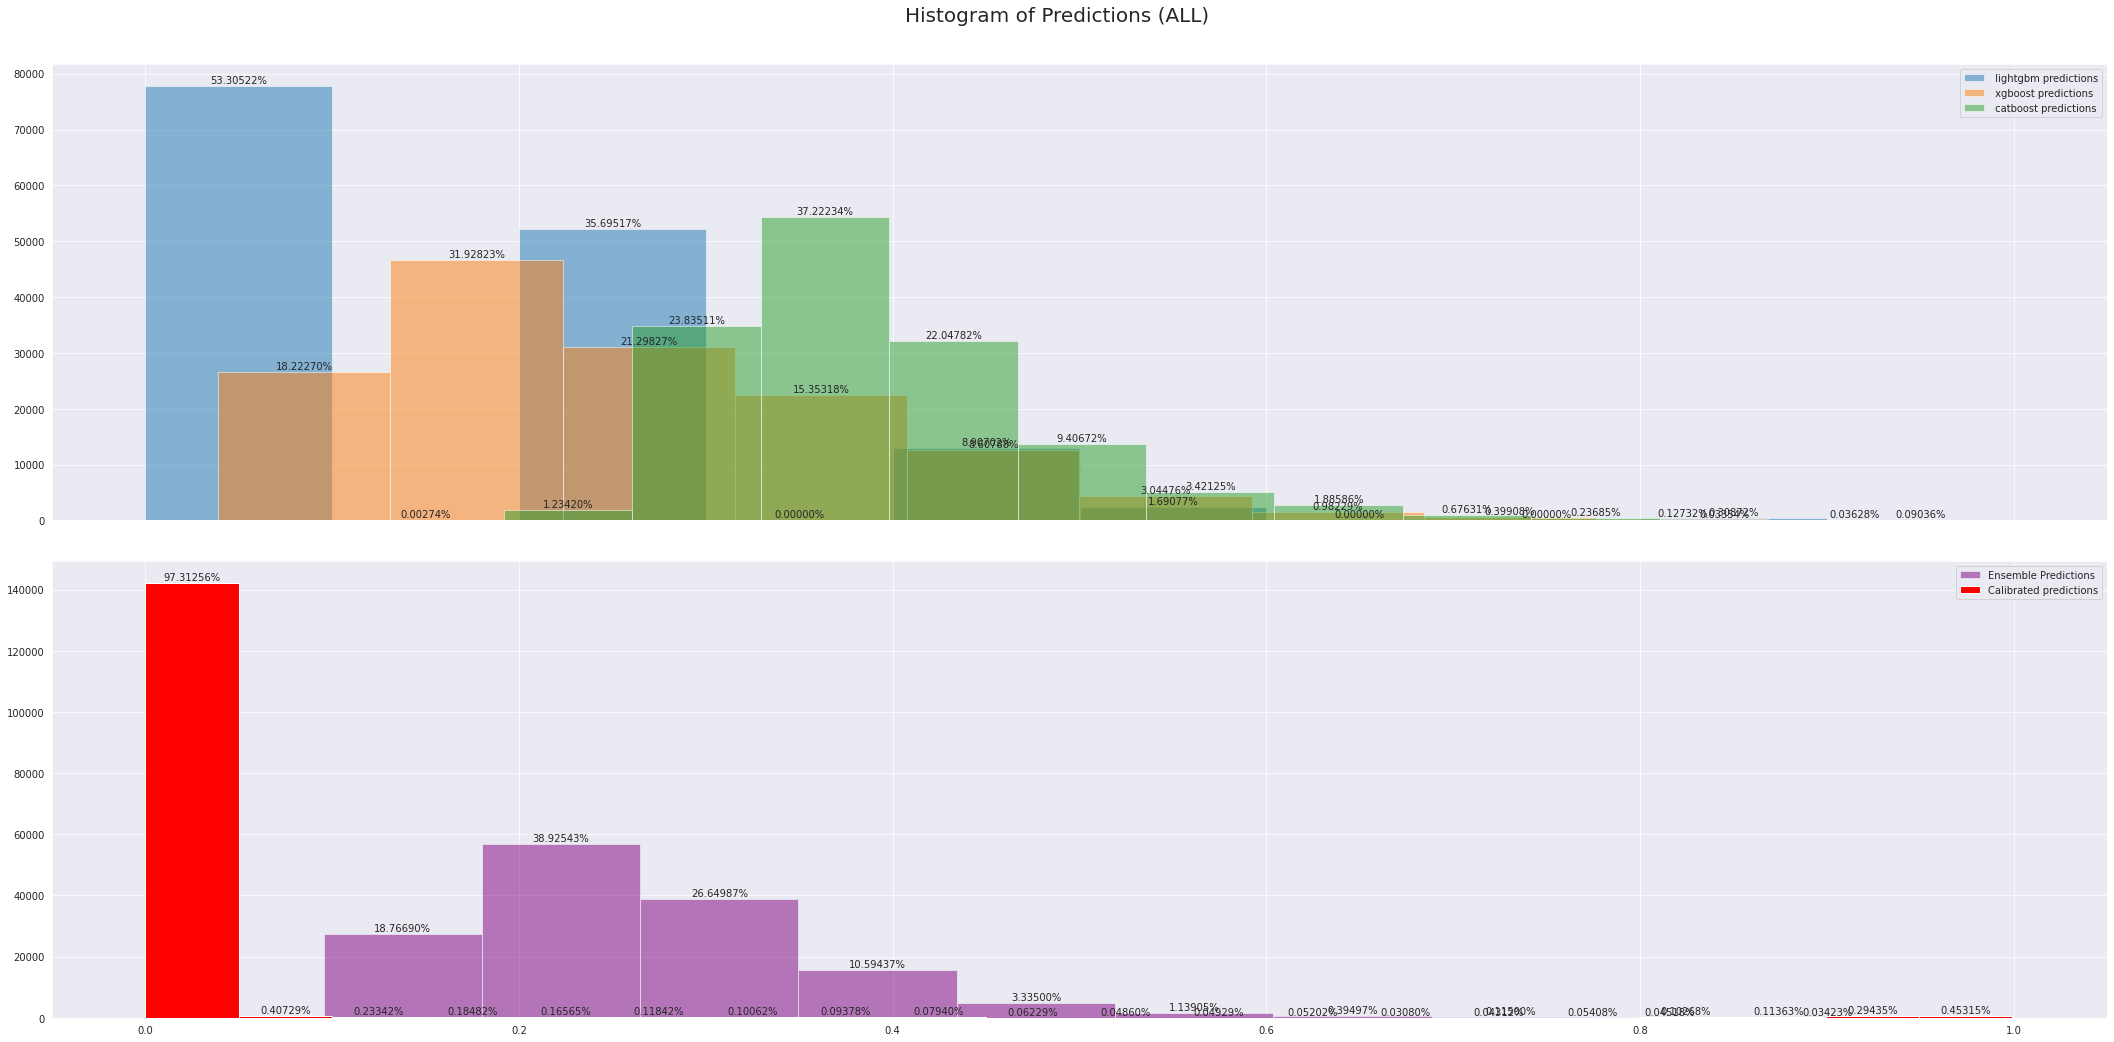

In [40]:
fig,ax = plt.subplots(2,1,figsize = (30,15),sharex = True)
for i in range(len(test_preds)):
    name = list(models)[i]
    ax[0].hist(test_preds[i],label = f" {name} predictions", alpha =0.5)
    ax[0].legend()
    
sub_ensemble[target].hist(ax = ax[1],label = "Ensemble Predictions",color = "purple", alpha = 0.5)
#sub_best_cv[target].hist(ax = ax[4],label = f"Best CV: {list(models)[np.argmax(OOF_val_score)]}", color = "green")
ax[1].hist(y_cal_test,label = f"Calibrated predictions", color = "red", bins = 20)
ax[1].legend()
fig.suptitle("Histogram of Predictions (ALL)", fontsize = 20)

total = len(y_cal_test)
for ax in [ax[0],ax[1]]:
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.5f}%\n'
        x = p.get_x() + p.get_width() / 2
        y_ = p.get_height()
        ax.annotate(percentage, (x, y_), ha='center', va='center')

plt.tight_layout(pad = 3)    
plt.show()

# 💥 Submission 💥

In [41]:
sub_ensemble.to_csv("sub_ensemble.csv")
sub_ensemble

,Class
id,
219129,0.287974
219130,0.285930
219131,0.156586
219132,0.314802
219133,0.208194
...,...
365211,0.195187
365212,0.229317
365213,0.241770


In [42]:
mean_ensemble.to_csv("mean_ensemble.csv")
mean_ensemble

,Class
id,
219129,0.281643
219130,0.279287
219131,0.146078
219132,0.306904
219133,0.195400
...,...
365211,0.183693
365212,0.215743
365213,0.228197


In [43]:
print(f"Best CV model: {list(models)[np.argmax(OOF_val_score)]}")

sub_lgb[target] = all_tst_preds.iloc[:,0].values
sub_lgb.to_csv("sub_lgb.csv")

sub_xgb[target] = all_tst_preds.iloc[:,1].values
sub_xgb.to_csv("sub_xgb.csv")

sub_cat[target] = all_tst_preds.iloc[:,2].values
sub_cat.to_csv("sub_cat.csv")
sub_xgb

Best CV model: catboost


,Class
id,
219129,0.245651
219130,0.222685
219131,0.117568
219132,0.276909
219133,0.212457
...,...
365211,0.223142
365212,0.258789
365213,0.308057


In [44]:
all_tst_preds.to_csv("test_preds.csv")
all_trn_preds.to_csv("train_preds.csv")
all_tst_preds

,lightgbm_0.7263105973208898,xgboost_0.8358409166523962,catboost_0.8918912069884597
id,,,
219129,0.2,0.245651,0.399279
219130,0.2,0.222685,0.415177
219131,0.0,0.117568,0.320666
219132,0.2,0.276909,0.443802
219133,0.0,0.212457,0.373742
...,...,...,...
365211,0.0,0.223142,0.327938
365212,0.0,0.258789,0.388440
365213,0.0,0.308057,0.376534


In [45]:
sub_cal.to_csv("sub_cal.csv")
sub_cal

,Class
id,
219129,6.155581e-08
219130,2.954386e-08
219131,9.586096e-08
219132,5.964996e-08
219133,3.620024e-07
...,...
365211,4.385574e-07
365212,1.771314e-07
365213,1.435188e-06
